# Lab 3.2 — ASR with Whisper: Transcription and Visualization
Upload beberapa file audio pendek (bisa rekam dulu di HP dalam Bahasa Inggris/Indonesia), lalu transkripsikan dengan Whisper dan visualisasikan Mel-spectrogram + timestamp kata.

In [1]:
!pip -q install openai-whisper torchaudio matplotlib
import whisper, torch
print('CUDA:', torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 11.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 6.3 MB/s eta 0:00:00
CUDA: False


## Upload audio Anda
Upload beberapa file .wav/.mp3 (mis. `my_speech.wav`, `english_sample.wav`, `indonesian_sample.wav`, `noisy_sample.wav`). Bisa direkam di HP lalu diunggah, atau memakai recorder JS Colab seperti pada Lab 3.5.

In [2]:
from google.colab import files
uploaded = files.upload()
print('File terunggah:', list(uploaded.keys()))

Saving freesound_community-sevendayslater-82332.mp3 to freesound_community-sevendayslater-82332.mp3
File terunggah: ['freesound_community-sevendayslater-82332.mp3']


In [3]:
AUDIO_FILE = list(uploaded.keys())[0]  # gunakan file pertama sebagai contoh utama
print('Menggunakan:', AUDIO_FILE)

Menggunakan: freesound_community-sevendayslater-82332.mp3


## 1. Load model dan transkripsi

In [4]:
model_tiny = whisper.load_model('tiny')
model_base = whisper.load_model('base')
print(f"Whisper tiny params: {sum(p.numel() for p in model_tiny.parameters()):,}")
print(f"Whisper base params: {sum(p.numel() for p in model_base.parameters()):,}")

result_tiny = model_tiny.transcribe(AUDIO_FILE, verbose=True)
result_base = model_base.transcribe(AUDIO_FILE, verbose=True)
print('\n[tiny]', result_tiny['text'])
print('[base]', result_base['text'])
print('Detected language:', result_base['language'])

100%|██████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 236MiB/s]
100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 110MiB/s]


Whisper tiny params: 37,184,640
Whisper base params: 71,825,920


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Detecting language using up to the first 30 seconds. Use `--language` to specify the language
Detected language: English
[00:00.000 --> 00:02.080]  spsy-ziato
Detecting language using up to the first 30 seconds. Use `--language` to specify the language


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Detected language: English
[00:00.000 --> 00:02.000]  7 days later

[tiny]  spsy-ziato
[base]  7 days later
Detected language: en


## 2. Visualisasi Mel-spectrogram

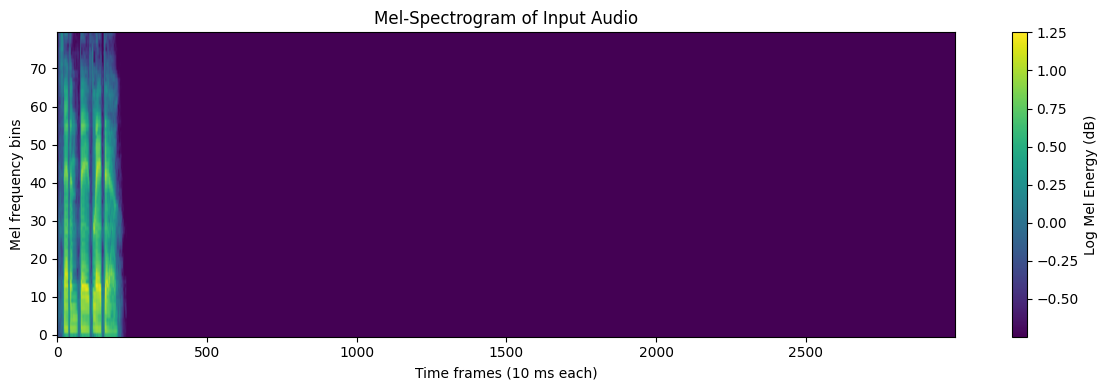

In [5]:
import matplotlib.pyplot as plt

audio = whisper.load_audio(AUDIO_FILE)
audio = whisper.pad_or_trim(audio)
mel = whisper.log_mel_spectrogram(audio)

plt.figure(figsize=(12, 4))
plt.imshow(mel.numpy(), aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Log Mel Energy (dB)')
plt.xlabel('Time frames (10 ms each)')
plt.ylabel('Mel frequency bins')
plt.title('Mel-Spectrogram of Input Audio')
plt.tight_layout(); plt.savefig('mel_spectrogram.png', dpi=150); plt.show()

## 3. Transkripsi multi-file (bandingkan English/Indonesian/Noisy)

In [6]:
print('=== Multi-clip Transcription ===')
for name in uploaded.keys():
    try:
        res = model_base.transcribe(name)
        print(f'[{name}] -> {res["text"]}')
    except Exception as e:
        print(f'[{name}] -> Error: {e}')

=== Multi-clip Transcription ===


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


[freesound_community-sevendayslater-82332.mp3] ->  7 days later


## 4. Word-level timestamps + anotasi spectrogram

In [7]:
result_ts = model_base.transcribe(AUDIO_FILE, word_timestamps=True)
print('=== Word-level Timestamps ===')
words_info = []
for segment in result_ts['segments']:
    for w in segment.get('words', []):
        print(f"'{w['word'].strip()}' [{w['start']:.2f}s - {w['end']:.2f}s]")
        words_info.append(w)

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


=== Word-level Timestamps ===
'7' [0.00s - 0.50s]
'days' [0.50s - 1.02s]
'later' [1.02s - 1.62s]


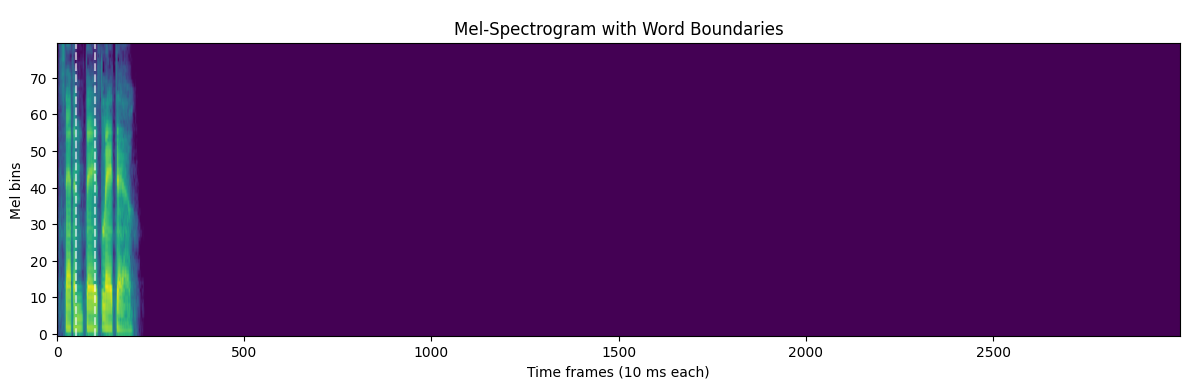

In [8]:
# Overlay word boundaries on the Mel-spectrogram (10ms per frame)
plt.figure(figsize=(12, 4))
plt.imshow(mel.numpy(), aspect='auto', origin='lower', cmap='viridis')
for w in words_info:
    frame_start = w['start'] * 100  # 10ms hop -> 100 frames/sec
    plt.axvline(frame_start, color='white', linestyle='--', alpha=0.6)
    plt.text(frame_start, 82, w['word'].strip(), color='white', fontsize=8, rotation=90)
plt.xlabel('Time frames (10 ms each)'); plt.ylabel('Mel bins')
plt.title('Mel-Spectrogram with Word Boundaries')
plt.tight_layout(); plt.savefig('mel_spectrogram_annotated.png', dpi=150); plt.show()